# Task Optimization: Dynamic Programming vs Greedy Algorithm

In [101]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src')
from IPython.display import display
from algorithms.knapsack import knapsack
from algorithms.greedy import greedy
from main import build_score_card
from data_generation import generate_dataset

## Introduction
When one is building a to-do list, users manually decide the order in which tasks are completed, typically mirroring a greedy approach. Most productivity tools with to-do lists adds a layer of functionality which allow tasks to be labeled by priority, yet the ordering of the task is still left to the user. The idea though is that if a task is flagged as a priority, it should be completed before the other tasks, and the primary constraint utilized here is time.

Yet this does not account for other factors, such as cognitive load which could affect how many tasks you can complete despite the time the user may have allotted or the number of tasks they wanted to complete.

This project will attempt to model task selection as an optimization problem in which both time and cognitive load are treated as constraints. Although the order of task selection is affected by many factors, the goal is to implement a dynamic programming solution and compare it to the baseline greedy approaches in order to evaluate whether the proposed system produces meaningfully different task selections.

## Research Question

*When both time and cognitive capacity are constrained, how does dynamic programming compare to greedy task-selection?*

## Data
We will be showcasing 4 datasets:

### Real Dataset
This is our primary dataset which consists of 10 tasks taken from a real to-do list. The duration estimates are based on typical completion time and priority scores was assigned based on personal importance for that day. Using a real dataset grounds the proof of concept in a realistic task distributions rather than purely synthetic data.

In [17]:
file = '../data/real_todo_list.csv'
primary_df = pd.read_csv(file)
print(primary_df)

                 task_name  duration  cognitive_cost  priority
0              Run 2 miles        45              20         7
1    Complete Peer Reviews        60               5         6
2           Complete Quiz         30               5         6
3   Read Literature Review       120              25         7
4                  Pilates        60              20        10
5         Meal Prep Dinner        60              10         5
6  Wash 2 Loads of Laundry        30               5         3
7        Complete Duolingo         5               1        10
8   Book Flights to Boston        10               1         6
9     Pick up Dry-Cleaning        15               3         1


### Divergence Dataset
Our divergence dataset is a hard-coded CSV file designed to stress test knapsack and greedy_ratio under tighter constraints.

In [15]:
file = '../data/divergence_todo_list.csv'
divergence_df = pd.read_csv(file)
print(divergence_df.tail())

                 task_name  duration  cognitive_cost  priority
8   Book Flights to Boston        10               1         6
9     Pick up Dry-Cleaning        15               3         1
10  Complete final project        70              40         9
11      Make Care Packages        30              20         6
12            Watch cousin        40              25         6


### Similar Priority
The next two datasets are synthetic generated data. The first is designed to test the algorithm's behavior when priorities are similar or clustered.

In [18]:
priorities_df = generate_dataset(n = 10, seed = 42, choice="similar priorities")
print(priorities_df.head())

  task_name  duration  cognitive_cost  priority
0    task_1         5              45        10
1    task_2        60              23         7
2    task_3        45              10         7
3    task_4        20              55         3
4    task_5        20              88         6


### High Correlation
This dataset is designed so that priority and cognitive cost is correlated. This means the higher the priority, the higher the cognitive cost.

In [19]:
correlation_df = generate_dataset(n = 10, seed = 42, choice="high correlation")
print(correlation_df.head())

  task_name  duration  cognitive_cost  priority
0    task_1        30              41         5
1    task_2       120              45         4
2    task_3        60              23         2
3    task_4        60              88         9
4    task_5        60              78         8


## Algorithm Demonstration

Set time_budget or the total time you allotted to complete any combination of tasks

In [20]:
time_budget = 240

Set the cog_budget or your total cognitive capacity out of 100 for the day

In [21]:
cog_budget = 80

Run knapsack algorithm


In [22]:
k_scheduled, k_unscheduled = knapsack(tasks = primary_df, capacity = cog_budget, time_budget = time_budget)

Run Greedy Algorithm ( 3 variations)
* Variation 1: The first variation represents real-world task selection where we choose tasks with high priority first
* Variation 2: The second variation represents real-world task selection where we choose tasks with the shortest duration
* Variation 3: The third variation represents real-world task selection where we choose tasks based on efficiency (highest priority per time)

It is also important to note that greedy does not account for cognitive capacity as we do not explicitly account for that when choosing tasks.

In [24]:
# highest priority
p_scheduled, p_unscheduled = greedy(tasks = primary_df, time_budget=time_budget, greedy_type = 0)
# shortest duration
d_scheduled, d_unscheduled = greedy(tasks = primary_df, time_budget=time_budget, greedy_type = 1)
# Highest priority per time
r_scheduled, r_unscheduled = greedy(tasks = primary_df, time_budget=time_budget, greedy_type = 2)

To build the score card, we first need to create a dictionary that houses all results

In [26]:
results = {
        "knapsack": {"scheduled": k_scheduled, "unscheduled": k_unscheduled},
        "greedy_priority": {"scheduled": p_scheduled, "unscheduled": p_unscheduled},
        "greedy_duration": {"scheduled": d_scheduled, "unscheduled": d_unscheduled},
        "greedy_ratio": {"scheduled": r_scheduled, "unscheduled": r_unscheduled},
}

score_card = build_score_card(task_df = primary_df, results=results, cog_budget=cog_budget, time_budget=time_budget)

To also see the task list in a more readable fashion, we created a helper function that can print the task list properly.

In [28]:
def print_task_list(scheduled, unscheduled, algorithm_implemented):
    """
    Prints a readable task list for passed algorithm
    :param scheduled: [list] scheduled tasks
    :param unscheduled: [list] unscheduled tasks
    :param algorithm_implemented: [str] name of algorithm
    :return: none
    """
    # Using ANSI escape codes to cross out the tasks that were not scheduled
    strikethrough_start = "\x1b[9m"
    reset = "\x1b[0m"

    print(f"\033[1mTask List for {algorithm_implemented}: \033[0m\n")
    task_list = []
    for task in scheduled:
        task_list.append(scheduled)
        print(f"* {task}")
    for task in unscheduled:
        print(f"* {strikethrough_start}{task}{reset}")
    return


In [29]:
print_task_list(results["knapsack"]["scheduled"], results["knapsack"]["unscheduled"], "Knapsack Algorithm")


Task List for Knapsack Algorithm: 

* Book Flights to Boston
* Complete Duolingo
* Wash 2 Loads of Laundry
* Pilates
* Complete Quiz 
* Complete Peer Reviews
* Run 2 miles
* Read Literature Review
* Meal Prep Dinner
* Pick up Dry-Cleaning


In [30]:
print_task_list(results["greedy_priority"]["scheduled"], results["greedy_priority"]["unscheduled"], "Greedy Algorithm (Highest Priority)")

Task List for Greedy Algorithm (Highest Priority): 

* Complete Duolingo
* Pilates
* Run 2 miles
* Read Literature Review
* Book Flights to Boston
* Complete Peer Reviews
* Complete Quiz 
* Meal Prep Dinner
* Wash 2 Loads of Laundry
* Pick up Dry-Cleaning


In [31]:
print_task_list(results["greedy_duration"]["scheduled"], results["greedy_duration"]["unscheduled"], "Greedy Algorithm (Shortest Duration)")

Task List for Greedy Algorithm (Shortest Duration): 

* Complete Duolingo
* Book Flights to Boston
* Pick up Dry-Cleaning
* Complete Quiz 
* Wash 2 Loads of Laundry
* Run 2 miles
* Pilates
* Complete Peer Reviews
* Read Literature Review
* Meal Prep Dinner


In [32]:
print_task_list(results["greedy_ratio"]["scheduled"], results["greedy_ratio"]["unscheduled"], "Greedy Algorithm (Highest Value Per Time)")

Task List for Greedy Algorithm (Highest Value Per Time): 

* Complete Duolingo
* Book Flights to Boston
* Complete Quiz 
* Pilates
* Run 2 miles
* Complete Peer Reviews
* Wash 2 Loads of Laundry
* Read Literature Review
* Meal Prep Dinner
* Pick up Dry-Cleaning


In [42]:
print(f"\033[1mScore Card\033[0m\n")
display(score_card)

Score Card



,Algorithm,Priority Score (%),Time Utilization (%),Cognitive Utilization (%),Tasks Utilization (%)
0,knapsack,100.000000,100.00,71.25,70.0
1,greedy_priority,83.333333,100.00,83.75,50.0
2,greedy_duration,89.583333,81.25,68.75,70.0
3,greedy_ratio,100.000000,100.00,71.25,70.0


## Validation

To evaluate that my algorithms are working correctly, we will create a new dataset that has 3 tasks. The user has a time budget of 60 minutes and cognitive budget of 20 out of 100.


| Task | Duration | Cognitive Cost | Priority |
|--: | --: | --: | --: |
|Task 1 | 30 | 10 | 5 |
|Task 2 | 40 | 15 | 8 |
|Task 3 | 20 | 5 | 3 |

In knapsack algorithm, the goal is maximize priority given duration and cognitive cost. Since selecting all three tasks would exceed both budgets (90 minutes, 30 cog), I considered all combinations of two tasks.


|     Combination | Duration | Cognitive Cost | Priority |
|----------------:|---------:|---------------:|---------:|
| Task 1 + Task 2 |       70 |             25 |       13 |
| Task 1 + Task 3 |       50 |             15 |        8 |
| Task 2 + Task 3 |       60 |             20 |       11 |



On inspection, the first combination has the highest priority, but exceeds both budgets. Task 2 and Task 3 would provide the maximum priority (Score 11) while meeting both constraints.

In [52]:
tasks = pd.DataFrame({
        'task_name': ['Task 1', 'Task 2', 'Task 3'],
        'duration': [30, 40, 20],
        'cognitive_cost': [10, 15, 5],
        'priority': [5,8,3]
    })

scheduled, unscheduled = knapsack(tasks, 20, 60)

print(f"\033[1mEvidence of Correctness: Knapsack\033[0m\n")
try:
    assert "Task 2" in scheduled
    assert "Task 3" in scheduled
    assert "Task 1" in unscheduled
    print("No error found in assertions")
except AssertionError:
    print("AssertionError thrown")

try:
    assert "Task 2" in unscheduled
except AssertionError:
    print(f'\nAssertionError thrown as expected - Task 2 should not be in unscheduled')

Evidence of Correctness: Knapsack

No error found in assertions

AssertionError thrown as expected - Task 2 should not be in unscheduled


| Task | Duration | Cognitive Cost | Priority |
|--: | --: | --: | --: |
|Task 2 | 40 | 15 | 8 |
|Task 1 | 30 | 10 | 5 |
|Task 3 | 20 | 5 | 3 |

For the greedy algorithm variation where highest priority is considered, it would sort by highest priority and continue until time budget is reached. Task 2 is the first scheduled as it has the highest priority. Task 1 will not be scheduled as although it has the next highest priority, we only have 20 minutes left in our budget. This would allow us to default to Task 3 being scheduled as it takes exactly 20 minutes.

| Task | Duration | Cognitive Cost | Priority |
|--: | --: | --: | --: |
|Task 3 | 20 | 5 | 3 |
|Task 1 | 30 | 10 | 5 |
|Task 2 | 40 | 15 | 8 |

For the greedy algorithm variation where shortest duration is considered, we would expect Task 3, which has the shortest duration of 20 minutes) to be selected first, followed by Task 1 (30 minutes) which would account for 50 out of the 60 minutes time budget. Therefore Task 2 will be unscheduled.

| Task | Duration | Cognitive Cost | Priority | Ratio |
|--: | --: | --: | --: |------:|
|Task 2 | 40 | 15 | 8 | 0.20 |
|Task 1 | 30 | 10 | 5 | 0.167 |
|Task 3 | 20 | 5 | 3 |  0.15 |

For the greedy algorithm variation where we want the most bang for our time, or highest priority per time, Task 2 has the highest ratio at 0.2 priority per minute.  Task 1 has a ratio is 0.167 priority per minute, but since it is over the budget (70/60 min), it will be unscheduled. Task 3 (0.15 priority per minute) would be scheduled as it falls under the time budget (50/60 min).

In [64]:
# highest priority
valid_p_scheduled, valid_p_unscheduled = greedy(tasks = tasks, time_budget=60, greedy_type = 0)
# shortest duration
valid_d_scheduled, valid_d_unscheduled = greedy(tasks = tasks, time_budget=60, greedy_type = 1)
# Highest priority per time
valid_r_scheduled, valid_r_unscheduled = greedy(tasks = tasks, time_budget=60, greedy_type = 2)

print(f"\033[1mEvidence of Correctness: Greedy (Highest Priority)\033[0m\n")
try:
    assert "Task 2" in valid_p_scheduled
    assert "Task 3" in valid_p_scheduled
    assert "Task 1" in valid_p_unscheduled
    print("No error found in assertions")
except AssertionError:
    print("AssertionError thrown")

print(f"\n\033[1mEvidence of Correctness: Greedy (Shorted Duration)\033[0m\n")
try:
    assert "Task 3" in valid_d_scheduled
    assert "Task 1" in valid_d_scheduled
    assert "Task 2" in valid_d_unscheduled
    print("No error found in assertions")
except AssertionError:
    print("AssertionError thrown")

print(f"\n\033[1mEvidence of Correctness: Greedy (Ratio)\033[0m\n")
try:
    assert "Task 2" in valid_r_scheduled
    assert "Task 3" in valid_r_scheduled
    assert "Task 1" in valid_r_unscheduled
    print("No error found in assertions")
except AssertionError:
    print("AssertionError thrown")

Evidence of Correctness: Greedy (Highest Priority)

No error found in assertions

Evidence of Correctness: Greedy (Shorted Duration)

No error found in assertions

Evidence of Correctness: Greedy (Ratio)

No error found in assertions


## Benchmarking

### Execution Time

I hypothesized that knapsack algorithm runs O(n_tasks * time * capacity)  and greedy runs O(n_tasks log n_tasks) due to the sorting.

In [72]:
def compute_performance_benchmarking(func, *args, **kwargs):
    start = time.time()
    func(*args, **kwargs)
    end = time.time()
    return end - start

In [73]:
# Create a list of to-do lists ranging from 10 tasks to 500 tasks
sizes = list(range(10, 500, 10))
knapsack_times = []
greedy_p_times = []
greedy_d_times = []
greedy_r_times = []

for n in sizes:
    df = generate_dataset(n=n, seed=42)
    knapsack_times.append(compute_performance_benchmarking(knapsack, df, 80, 240))
    greedy_p_times.append(compute_performance_benchmarking(greedy, df, 240, 0))
    greedy_d_times.append(compute_performance_benchmarking(greedy, df, 240, 1))
    greedy_r_times.append(compute_performance_benchmarking(greedy, df, 240, 2))


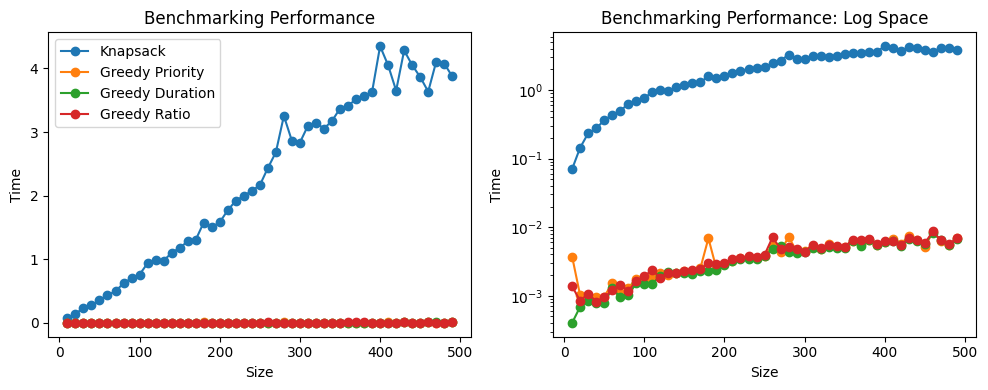

In [91]:
# Build a figure with 1 row two columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for ax, log in zip([ax1, ax2], [False, True]):
    ax.plot(sizes, knapsack_times, marker="o", label="Knapsack")
    ax.plot(sizes, greedy_p_times, marker="o", label="Greedy Priority")
    ax.plot(sizes, greedy_d_times, marker="o", label="Greedy Duration")
    ax.plot(sizes, greedy_r_times, marker="o", label="Greedy Ratio")
    ax.set_xlabel('Size')
    ax.set_ylabel('Time')
    if log:
        ax.set_yscale("log")
        ax.set_title('Benchmarking Performance: Log Space')
    else:
        ax.set_title('Benchmarking Performance')
        ax.legend()



plt.tight_layout()
plt.show()
plt.close()

The graphs showcase the performance of both algorithms and confirms my hypothesis.

It appears the knapsack performance grows in a curve with dataset size, consistent with its O(n_tasks * time * capacity) complexity, while all three greedy variations stayed near 0. In order to get a better picture of what is occurring, the right image shows the same data but in log space. This revealed that greedy runtime is increasing with the number of tasks but slowly, consistent with its O(n_tasks log n_tasks) sorting complexity. All three of the greedy variations are identical, which supports the sorting step is a major step in runtime.

To truly see knapsack true performance, we would also need to scale the budgets with n, which is a current limitation of this benchmark.

## Discussion

### Dataset Comparison
Our next goal is to visually compare the differences across our datasets we introduced earlier in the notebook.

In [94]:
datasets = [divergence_df, priorities_df, correlation_df]
scorecards = []
# Append Real dataset scorecard since it has already been implemented
scorecards.append(score_card)

time_budget = 240
cog_budget = 80

for dataset in datasets:
    # knapsack
    k_scheduled, k_unscheduled = knapsack(tasks = dataset, capacity = cog_budget, time_budget = time_budget)
    # highest priority
    p_scheduled, p_unscheduled = greedy(tasks = dataset, time_budget=time_budget, greedy_type = 0)
    # shortest duration
    d_scheduled, d_unscheduled = greedy(tasks = dataset, time_budget=time_budget, greedy_type = 1)
    # Highest priority per time
    r_scheduled, r_unscheduled = greedy(tasks = dataset, time_budget=time_budget, greedy_type = 2)

    results = {
        "knapsack": {"scheduled": k_scheduled, "unscheduled": k_unscheduled},
        "greedy_priority": {"scheduled": p_scheduled, "unscheduled": p_unscheduled},
        "greedy_duration": {"scheduled": d_scheduled, "unscheduled": d_unscheduled},
        "greedy_ratio": {"scheduled": r_scheduled, "unscheduled": r_unscheduled},
    }

    score_card = build_score_card(task_df = dataset, results=results, cog_budget=cog_budget, time_budget=time_budget)

    scorecards.append(score_card)

In [99]:
dataset_names = ["Real", "Divergence", "Similar Priorities", "High Correlation"]
for i, scorecard in enumerate(scorecards):
    print(f"\033[1m{dataset_names[i]}\033[0m\n")
    display(scorecard)

Real



,Algorithm,Priority Score (%),Time Utilization (%),Cognitive Utilization (%),Tasks Utilization (%)
0,knapsack,100.000000,100.00,71.25,70.0
1,greedy_priority,83.333333,100.00,83.75,50.0
2,greedy_duration,89.583333,81.25,68.75,70.0
3,greedy_ratio,100.000000,100.00,71.25,70.0


Divergence



,Algorithm,Priority Score (%),Time Utilization (%),Cognitive Utilization (%),Tasks Utilization (%)
0,knapsack,100.000000,100.000000,90.00,53.846154
1,greedy_priority,96.078431,97.916667,112.50,53.846154
2,greedy_duration,88.235294,85.416667,100.00,61.538462
3,greedy_ratio,101.960784,97.916667,118.75,61.538462


Similar Priorities



,Algorithm,Priority Score (%),Time Utilization (%),Cognitive Utilization (%),Tasks Utilization (%)
0,knapsack,100.000000,85.416667,85.00,40.0
1,greedy_priority,233.333333,95.833333,598.75,90.0
2,greedy_duration,233.333333,95.833333,598.75,90.0
3,greedy_ratio,233.333333,95.833333,598.75,90.0


High Correlation



,Algorithm,Priority Score (%),Time Utilization (%),Cognitive Utilization (%),Tasks Utilization (%)
0,knapsack,100.000000,25.000000,90.0,20.0
1,greedy_priority,344.444444,91.666667,395.0,40.0
2,greedy_duration,422.222222,91.666667,440.0,60.0
3,greedy_ratio,422.222222,91.666667,440.0,60.0


The scorecards provides four evaluation columns:
* Priority Score (%) is the total score as compared to the knapsack algorithm as our base case. This was designed as our goal is to compare greedy to the knapsack algorithm.
* Time Utilization (%) is the total time scheduled divided by the time budget to see how well the algorithms used the time budgeted.
* Cognitive Utilization (%)	is the total cognitive capacity scheduled divided by the cognitive budger to see how well the algorithms used the cognitive load budgeted.
* Tasks Utilization (%) is the total of tasks scheduled divided by the total tasks listed to calculate the percentage of tasks scheduled.

### Real Dataset
**Observations**
* The knapsack algorithm and greedy ratio algorithm provided the same scheduled and unscheduled lists so their score card is the same.
* Greedy Priority and Greedy duration had lesser total priority scores than knapsack.
* All algorithms utilized the total time allotted except greedy shortest duration which is expected as this algorithm prioritized tasks with shorter time which means it may the time left might be too small to add remaining tasks.
* Greedy shortest uses the least amount of cognitive capacity allotted whereas both knapsack and greedy ratio uses ~71%. Greedy priority uses 80%.
* Despite greedy priority having no cognitive constraint, it still only scheduled half the tasks compared to the other algorithms which scheduled 70% of the tasks. This is because greedy priority grabs the high-priority tasks first which seems to consume the time-budget early, depleting the time budget so that no additional tasks could be scheduled.

Knapsack matched greedy_ratio on all metrics while outperforming greedy_priority and greedy-duration on priority score. This suggests that explicitly accounting for cognitive load as a constraint does not come at the cost of time utilization.


## Divergence Dataset
This was created so we can see how greedy_ratio and knapsack compared.

**Observations**
* Greedy ratio achieved a higher priority score than knapsack.
* Knapsack utilized total time allotted, while greedy ratio utilized ~98%.
* Knapsack utilized 90% cognitive load, whereas greedy ratio utilized 118.75%. This is a great indicator of how greedy does not account for cognitive capacity as greedy priority also went over cognitive capacity.
* Knapsack scheduled 54% of the tasks whereas greedy ratio scheduled 62%.

Greedy ratio outperformed individually in task utilization and in scheduled prioritized tasks. Yet knapsack still outperformed as it accounted for cognitive capacity whereas greedy exceeded the cognitive budget by 18.75% . These results are not directly comparable since greedy did not operate with cognitive awareness. Yet this does highlight my argument that greedy algorithm does provide optimal metrics but may not be sustainable in the long term.

## Similar Priorities Dataset
This is a stress test to see how well the algorithms behave when given similar priorities.

**Observations**
* All three greedy algorithms performed the same.
* All three greedy algorithms exceeded the cognitive utilization.

Greedy appears to behave the same despite the different sorting methods as it could not differentiate well due to the similar priorities. The greedy algorithms scheduled 90% of the tasks offered and with more priority tasks but at the expense of the cognitive capacity. On the other hand, knapsack only scheduled 40% of the tasks as it reached 85% cognitive capacity and time utilization. This is also a great example of how taking only time and priority can look great but does not sustain productivity.

## High Correlation Dataset
This is a stress test to test how highly correlated data can affect both algorithms in task optimization.

**Observation**
* Knapsack only used 25% of its time budget and scheduled *20%* of the tasks.
* Greedy algorithms utilized more time but scheduled 40-60% of tasks.

Knapsack did not handle highly correlated data well as tasks since if a task had high priority it also had high cognitive capacity. The knapsack hits the cognitive budget quicker (90% cognitive load utilized) but at the expense of scheduling many tasks and time is not as big of a factor. Due to the design mentioned earlier, that is also why greedy utilization was lower as well, although it did maximize on time better.

## Summary

When I designed this I wanted to make it as real-world as possible, which also meant that my greedy algorithm design was not directly comparable to the knapsack algorithm since the greedy algorithm does not account for cognitive capacity. With that being said, I do think based on the stress tests, it is comparable as it did just as well as the greedy ratio test on the real-world dataset. I also think the stress tests outlined how greedy algorithms provide great metrics but at the cost of your capacity levels which highlights how greedy is not promised to provide the most sustainable solution. On the other hand, knapsack provided comparable and guaranteed optimal solutions within both constraints, excluding the high correlation dataset which limited task selection for both algorithms.